# EEG Biometric Authentication — Riemannian Potato

**Enrolled on**: ziyang 1230 (raw)  
**Evaluated on**: 2000-session data from `data/interim/` — all 4 subjects (ziyang, chris, josua, mehak)

- ziyang 2000 → should ACCEPT (cross-session FRR test)
- chris / josua / mehak 2000 → should REJECT (FAR test; mehak is unseen during training)

In [ ]:
import sys; sys.path.insert(0, '/home/josua/Projects/hackathon_zeiss/brain_id')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from riemann_potato import (load_csv, preprocess, epoch, to_covs,
                  enroll_multi, verify_multi,
                  OCC_CHANNELS, RATE_TO_FREQ,
                  save_potatoes, load_potatoes)
RATES = ['10hz']
print('imports ok')

imports ok


## 1. Enroll — ziyang 1230 (narrow bandpass + CAR + occipital channels ch5–ch8)

In [12]:
ENROLL_CSVS = {
    '10hz': '/home/josua/Projects/hackathon_zeiss/brain_id/data/raw/2000_ziyang_10hz.csv',
}

# enroll_multi auto-applies narrow bandpass per rate + CAR + occipital channels
potatoes = enroll_multi(ENROLL_CSVS)
save_potatoes(potatoes, '../models/ziyang_potatoes_v2.pkl')
print('Enrollment done.')

  enrollment: 71 clean epochs  [2000_ziyang_10hz.csv]
Saved ['10hz'] → ../models/ziyang_potatoes_v2.pkl
Enrollment done.


## 2. Verify — collect z-scores per subject × rate

In [15]:
INTERIM = '../data/interim/10hz/'
RATES_AVAIL = ['10hz']   # only 10hz recorded for all 2000-session subjects

TEST_CSVS = {
    'ziyang_1230': {'10hz': '../data/raw/1230_ziyang_10hz.csv'},   # enrollment ref
    # 'ziyang_2000': {'10hz': f'{INTERIM}2000_ziyang_10hz.csv'},     # cross-session self
    'chris_2000':  {'10hz': f'{INTERIM}2000_chris_10hz.csv'},
    'josua_2000':  {'10hz': f'{INTERIM}2000_josua_10hz.csv'},
    'mehak_2000':  {'10hz': f'{INTERIM}2000_mehak_10hz.csv'},      # never seen before
}

zscores = {}; results = {}
for subject, rate_csvs in TEST_CSVS.items():
    zscores[subject] = {}; results[subject] = {}
    for rate, path in rate_csvs.items():
        if rate not in potatoes:
            continue
        ssvep_freq = RATE_TO_FREQ.get(rate)
        X = preprocess(load_csv(path, OCC_CHANNELS), ssvep_freq)
        covs = to_covs(epoch(X))
        labels = potatoes[rate].predict(covs)
        zscores[subject][rate] = potatoes[rate].transform(covs)
        results[subject][rate] = {
            'decision':    'ACCEPT' if labels.mean() > 0.5 else 'REJECT',
            'accept_rate': round(float(labels.mean()), 3),
            'mean_zscore': round(float(zscores[subject][rate].mean()), 3),
            'n_epochs':    len(covs),
        }
print('Verification done.')

Verification done.


## 3. Summary table

In [16]:
rows = []
for subject, rate_results in results.items():
    for rate, r in rate_results.items():
        rows.append({'subject': subject, 'rate': rate, 'decision': r['decision'],
                     'accept_rate': r['accept_rate'], 'mean_zscore': r['mean_zscore'],
                     'n_epochs': r['n_epochs']})
df = pd.DataFrame(rows)
def color_decision(val):
    return 'background-color: #c8e6c9' if val == 'ACCEPT' else 'background-color: #ffcdd2'
df.style.map(color_decision, subset=['decision'])

,subject,rate,decision,accept_rate,mean_zscore,n_epochs
0,ziyang_1230,10hz,ACCEPT,0.984000,0.952000,128
1,chris_2000,10hz,ACCEPT,0.948000,1.092000,96
2,josua_2000,10hz,REJECT,0.121000,2.818000,66
3,mehak_2000,10hz,ACCEPT,0.985000,0.745000,66


## 4. Z-score distributions per rate

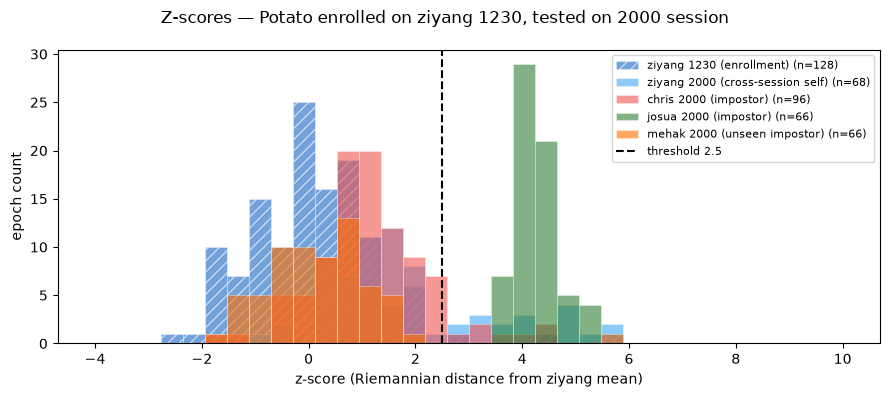

In [5]:
SUBJECT_STYLE = {
    'ziyang_1230': ('#1565C0', '///', 'ziyang 1230 (enrollment)'),
    'ziyang_2000': ('#42A5F5', '',    'ziyang 2000 (cross-session self)'),
    'chris_2000':  ('#EF5350', '',    'chris 2000 (impostor)'),
    'josua_2000':  ('#2E7D32', '',    'josua 2000 (impostor)'),
    'mehak_2000':  ('#FF6F00', '',    'mehak 2000 (unseen impostor)'),
}
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Z-scores — Potato enrolled on ziyang 1230, tested on 2000 session', fontsize=12)
bins = np.linspace(-4, 10, 35)
for subject, (color, hatch, label) in SUBJECT_STYLE.items():
    z = zscores.get(subject, {}).get('10hz')
    if z is None: continue
    ax.hist(z, bins=bins, alpha=0.6, color=color, hatch=hatch,
            label=f'{label} (n={len(z)})', edgecolor='white', linewidth=0.4)
ax.axvline(2.5, color='black', linewidth=1.5, linestyle='--', label='threshold 2.5')
ax.set_xlabel('z-score (Riemannian distance from ziyang mean)'); ax.set_ylabel('epoch count')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/14_zscore_2000session.png', dpi=150)
plt.show()

## 5. Accept rates — 2000 session

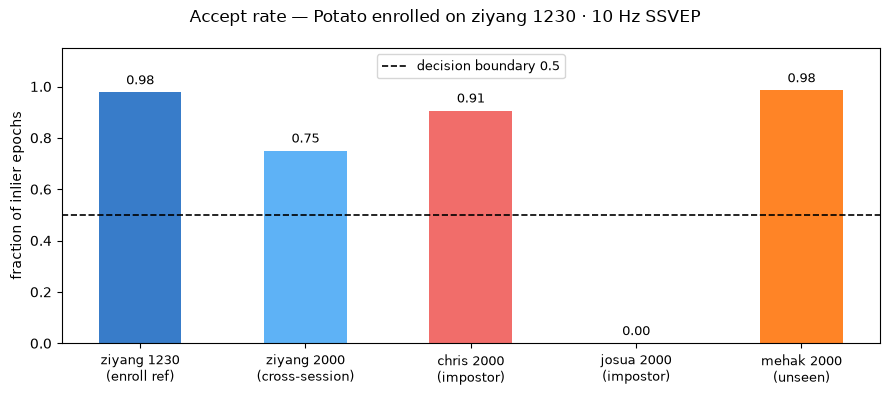

In [6]:
subjects_ordered = ['ziyang_1230', 'ziyang_2000', 'chris_2000', 'josua_2000', 'mehak_2000']
labels_ordered   = ['ziyang 1230\n(enroll ref)', 'ziyang 2000\n(cross-session)',
                    'chris 2000\n(impostor)', 'josua 2000\n(impostor)', 'mehak 2000\n(unseen)']
bar_colors       = ['#1565C0', '#42A5F5', '#EF5350', '#2E7D32', '#FF6F00']

rate = '10hz'
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Accept rate — Potato enrolled on ziyang 1230 · 10 Hz SSVEP', fontsize=12)
x = np.arange(len(subjects_ordered))
vals = [results.get(s, {}).get(rate, {}).get('accept_rate', np.nan) for s in subjects_ordered]
bars = ax.bar(x, vals, color=bar_colors, alpha=0.85, width=0.5)
ax.axhline(0.5, color='black', linewidth=1.2, linestyle='--', label='decision boundary 0.5')
ax.set_xticks(x); ax.set_xticklabels(labels_ordered, fontsize=9)
ax.set_ylabel('fraction of inlier epochs'); ax.set_ylim(0, 1.15)
for bar, val in zip(bars, vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}',
                ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/15_accept_rates_2000session.png', dpi=150)
plt.show()

## 6. PCA (n=3) of covariance matrices — 5 Hz (narrow bandpass + CAR + occipital ch5–ch8)

Explained variance: PC1=62.0%  PC2=23.0%  PC3=6.3%  total=91.3%


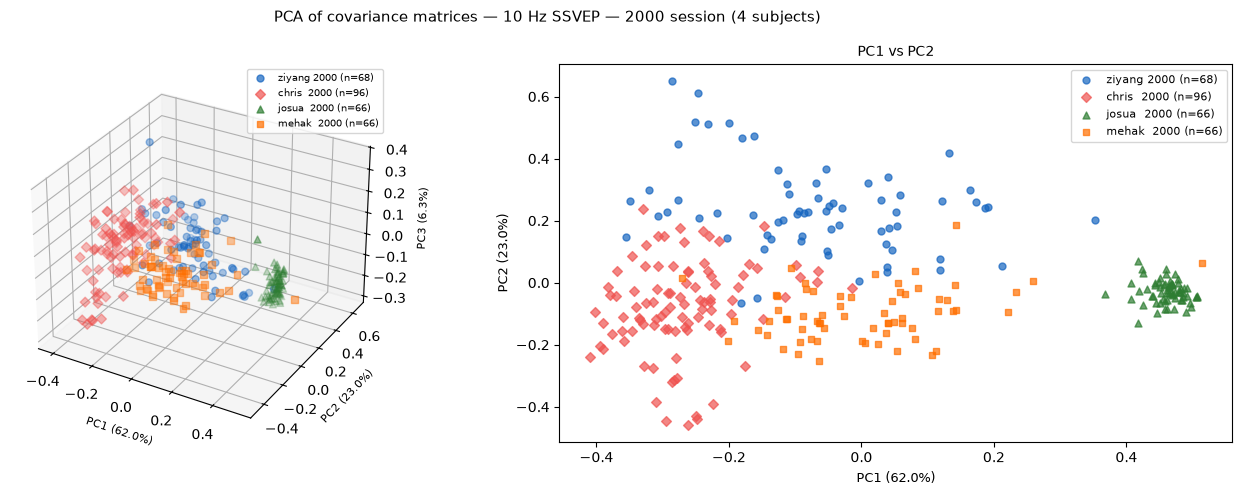

In [7]:
from sklearn.decomposition import PCA

groups = {
    'ziyang 2000': f'{INTERIM}2000_ziyang_10hz.csv',
    'chris  2000': f'{INTERIM}2000_chris_10hz.csv',
    'josua  2000': f'{INTERIM}2000_josua_10hz.csv',
    'mehak  2000': f'{INTERIM}2000_mehak_10hz.csv',
}
colors  = {'ziyang 2000': '#1565C0', 'chris  2000': '#EF5350',
           'josua  2000': '#2E7D32', 'mehak  2000': '#FF6F00'}
markers = {'ziyang 2000': 'o', 'chris  2000': 'D',
           'josua  2000': '^', 'mehak  2000': 's'}

def covs_preprocessed(csv_path, ssvep_freq=10.0):
    X = load_csv(csv_path, OCC_CHANNELS)
    X = preprocess(X, ssvep_freq=ssvep_freq)
    return to_covs(epoch(X))

n_ch = len(OCC_CHANNELS)
idx = np.triu_indices(n_ch, k=0)
all_vecs, all_labels, group_sizes = [], [], {}
for name, path in groups.items():
    covs = covs_preprocessed(path)
    vecs = covs[:, idx[0], idx[1]]
    all_vecs.append(vecs)
    all_labels.extend([name] * len(vecs))
    group_sizes[name] = len(vecs)

X_all = np.vstack(all_vecs)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_all)
var = pca.explained_variance_ratio_ * 100
print(f'Explained variance: PC1={var[0]:.1f}%  PC2={var[1]:.1f}%  PC3={var[2]:.1f}%  total={sum(var):.1f}%')

fig = plt.figure(figsize=(14, 5))
fig.suptitle('PCA of covariance matrices — 10 Hz SSVEP — 2000 session (4 subjects)', fontsize=11)
ax3d = fig.add_subplot(121, projection='3d')
ax2d = fig.add_subplot(122)

start = 0
for name in groups:
    n = group_sizes[name]
    pts = X_pca[start:start+n]
    kw = dict(c=colors[name], marker=markers[name], s=25, alpha=0.7, label=f'{name} (n={n})')
    ax3d.scatter(pts[:,0], pts[:,1], pts[:,2], **kw)
    ax2d.scatter(pts[:,0], pts[:,1], **kw)
    start += n

ax3d.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=8)
ax3d.set_ylabel(f'PC2 ({var[1]:.1f}%)', fontsize=8)
ax3d.set_zlabel(f'PC3 ({var[2]:.1f}%)', fontsize=8)
ax3d.legend(fontsize=7)
ax2d.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=9)
ax2d.set_ylabel(f'PC2 ({var[1]:.1f}%)', fontsize=9)
ax2d.set_title('PC1 vs PC2', fontsize=10)
ax2d.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/16_pca_2000session.png', dpi=150)
plt.show()

In [ ]:
from pyriemann.tangentspace import TangentSpace
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

SSVEP_FREQ = 10.0

def load_covs(path):
    X = load_csv(path, OCC_CHANNELS)
    X = preprocess(X, ssvep_freq=SSVEP_FREQ)
    return to_covs(epoch(X))

# Train: ziyang 1230 (user) + 2000-session impostors
train_sources = {
    'ziyang_1230': ('../data/raw/1230_ziyang_10hz.csv',    1),
    'chris_2000':  (f'{INTERIM}2000_chris_10hz.csv',       0),
    'josua_2000':  (f'{INTERIM}2000_josua_10hz.csv',       0),
    'mehak_2000':  (f'{INTERIM}2000_mehak_10hz.csv',       0),
}
# Hold-out: ziyang 2000 (cross-session — never seen in training)
test_sources = {
    'ziyang_2000': (f'{INTERIM}2000_ziyang_10hz.csv',      1),
    'chris_2000':  (f'{INTERIM}2000_chris_10hz.csv',       0),
    'josua_2000':  (f'{INTERIM}2000_josua_10hz.csv',       0),
    'mehak_2000':  (f'{INTERIM}2000_mehak_10hz.csv',       0),
}

X_tr, y_tr, tr_names = [], [], []
for name, (path, label) in train_sources.items():
    c = load_covs(path); X_tr.append(c)
    y_tr.extend([label]*len(c)); tr_names.extend([name]*len(c))
X_tr = np.concatenate(X_tr); y_tr = np.array(y_tr)

X_te, y_te, te_names = [], [], []
for name, (path, label) in test_sources.items():
    c = load_covs(path); X_te.append(c)
    y_te.extend([label]*len(c)); te_names.extend([name]*len(c))
X_te = np.concatenate(X_te); y_te = np.array(y_te); te_names = np.array(te_names)

ts  = TangentSpace(metric='riemann')
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    CalibratedClassifierCV(SVC(kernel='rbf', C=1.0, class_weight='balanced'), ensemble=False)),
])
clf.fit(ts.fit_transform(X_tr), y_tr)

y_pred  = clf.predict(ts.transform(X_te))
y_proba = clf.predict_proba(ts.transform(X_te))[:, 1]

print("=== SVM — hold-out: ziyang 2000 (cross-session) + 2000 impostors ===\n")
print(classification_report(y_te, y_pred, target_names=['impostor', 'ziyang']))

print(f"\n{'subject':<15} {'label':>10}  {'accept_rate':>12}  {'mean_P(zy)':>12}")
print("-" * 55)
for name in dict.fromkeys(te_names):
    mask = te_names == name
    tag  = '(self)' if y_te[mask][0] == 1 else '(impostor)'
    print(f"  {name:<13} {tag:>10}   {y_pred[mask].mean():>10.3f}   {y_proba[mask].mean():>10.3f}")

=== SVM — hold-out: ziyang 2000 (cross-session) + 2000 impostors ===

              precision    recall  f1-score   support

    impostor       0.79      0.92      0.85       228
      ziyang       0.42      0.21      0.28        68

    accuracy                           0.75       296
   macro avg       0.61      0.56      0.56       296
weighted avg       0.71      0.75      0.72       296


subject              label   accept_rate    mean_P(zy)
-------------------------------------------------------
  ziyang_2000       (self)        0.206        0.300
  chris_2000    (impostor)        0.073        0.164
  josua_2000    (impostor)        0.000        0.069
  mehak_2000    (impostor)        0.182        0.279
